In [ ]:

# -*- coding: utf-8 -*-
#  Copyright 2023 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by:  Jacob Filik (Diamond Light Source Ltd.)



# Laminography Reconstruction of Tomobank Brain slab dataset

The X-ray Tomography Data Bank or TomoBank [1], provides a repository of experimental and simulated data sets with the aim to foster collaboration among computational scientists, beamline scientists and experimentalists, to accelerate the development of tomographic reconstruction and 3D visualization methods and to speed up their implementation in the various synchrotron facility data analysis software packages.

Inside this repository is a Laminography measurement of a Brain Slab measured with parallel beam at the APS [2].

This notebook documents a simple reconstruction of this dataset using Filtered Back Projection.

CIL version: 24.3.0

[1] De Carlo, Francesco, et al. “TomoBank: a tomographic data repository for computational x-ray science.” Measurement Science and Technology 29.3 (2018): 034004. http://www.doi.org/10.1088/1361-6501/aa9c19

[2] Nikitin, Viktor, el al. "Laminography as a tool for imaging large-size samples with high resolution" Journal of Synchrotron Radiation 31 4 2024 851-866. https://doi.org/10.1107/S1600577524002923 

Download brain_x2y1.h5 from tomobank via globus and set the filepath in the cell below

In [2]:
filepath = "/scratch2/data/tomo_bank/brain_x2y1.h5"

In [3]:
import h5py
import numpy as np

from cil.framework import AcquisitionGeometry, AcquisitionData
from cil.processors import TransmissionAbsorptionConverter, Normaliser, Padder, Slicer
from cil.recon import FBP
from cil.utilities.display import show2D, show_geometry


The raw data is quite large, so for this simple demonstration we will downsample the data quite heavily in both the image and theta

In [4]:
downsample_step = 8

with h5py.File("/scratch2/data/tomo_bank/brain_x2y1.h5") as fh:

    data = fh["/exchange/data"][::downsample_step,::downsample_step,::downsample_step]
    dark = fh["/exchange/data_dark"][:,::downsample_step,::downsample_step]
    white = fh["/exchange/data_white"][:,::downsample_step,::downsample_step]


Initialise the geometry for parallel beam laminography with a tilt of 19.95 degrees (value from journal article)

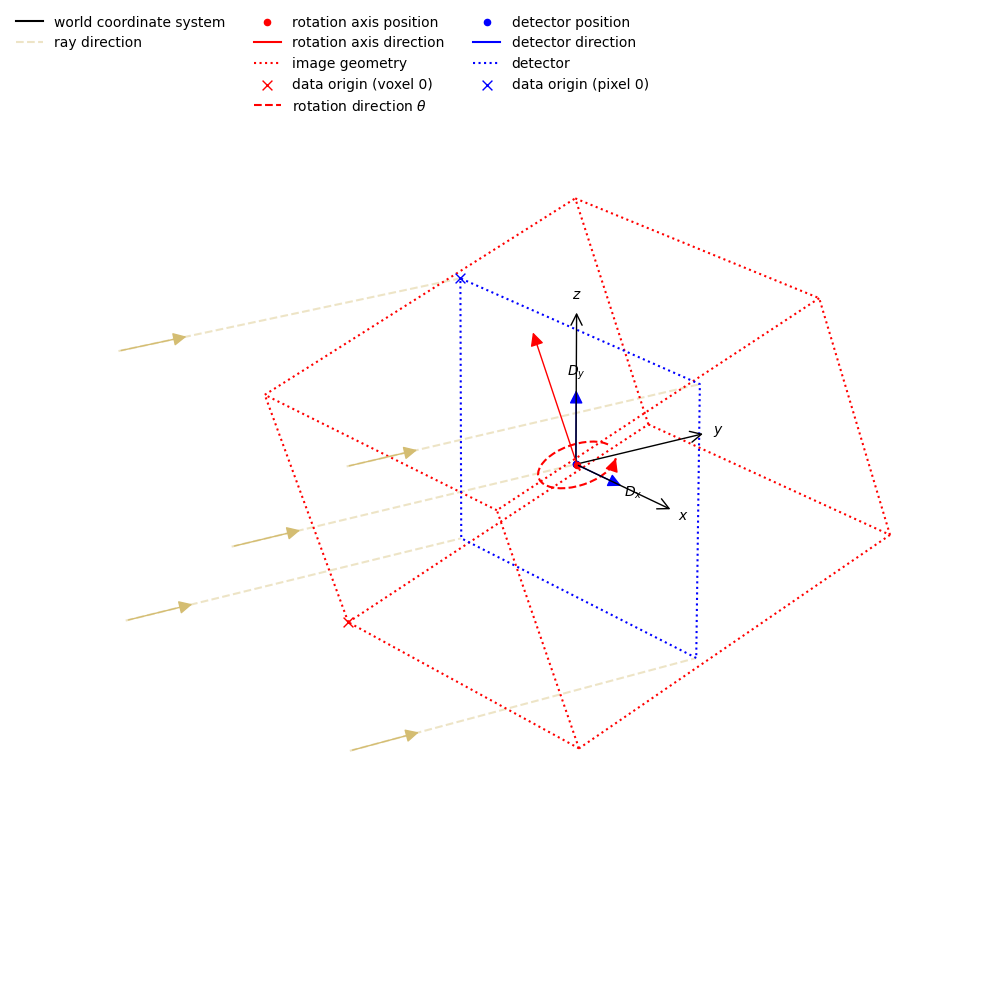

In [6]:

tilt = 19.95* np.pi / 180.
centre_of_rotation = 2

angles_list = np.linspace(0, 360, data.shape[0], endpoint=False)
num_pixels_x = data.shape[2]
num_pixels_y = data.shape[1]
pixel_size_xy = 1

rot_axis = [0,-np.sin(tilt), np.cos(tilt)]

ag = AcquisitionGeometry.create_Parallel3D(rotation_axis_position=[centre_of_rotation,0,0],\
                                         rotation_axis_direction=rot_axis)\
.set_angles(angles=angles_list, angle_unit='degree')\
.set_panel( num_pixels=[num_pixels_x, num_pixels_y], \
                                    pixel_size=pixel_size_xy,\
                                    origin='top-left')\
.set_labels(['vertical','angle','horizontal'])

_ = show_geometry(ag)


Dark/Flat correct the projections

In [8]:
dark_av = dark.mean(axis = 0)
white_av = white.mean(axis = 0)

frame_data = (data - dark_av) / (white_av - dark_av)
frame_data = frame_data.astype(np.float32).transpose([1,0,2])

Create Acquistion data from projections and geometry

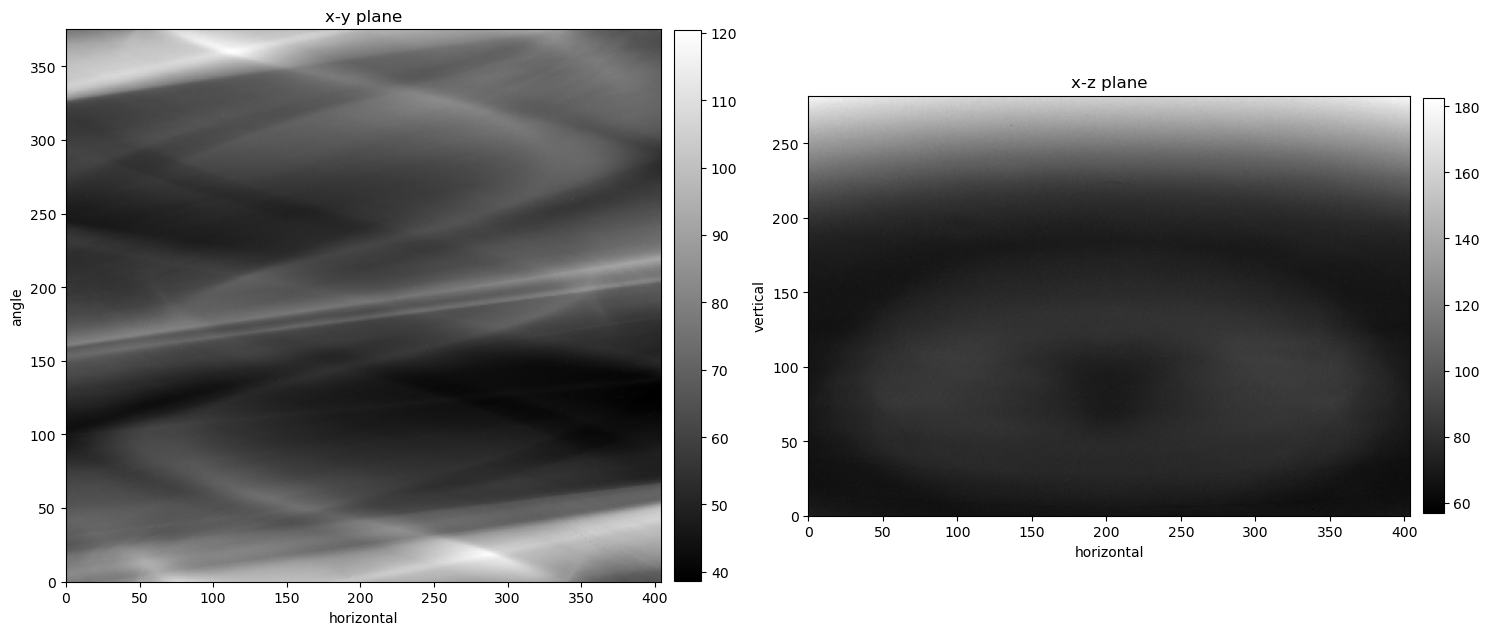

In [10]:
acq_data_SC = AcquisitionData(array=frame_data, geometry=ag)

_ = show2D([acq_data_SC.sum(axis=0),acq_data_SC.sum(axis=1)],title=['x-y plane','x-z plane'])


Convert the data to absorption, pad (its a region of interest measurement), and run the FBP.

In [11]:
converter = TransmissionAbsorptionConverter()
acq_data = converter(acq_data_SC)
processor = Padder.edge(pad_width= {'horizontal':(100, 100), 'vertical': 0})
processor.set_input(acq_data)
acq_data_pad = processor.get_output()
reconstructor = FBP(acq_data_pad, backend="astra")
FBP_reco = reconstructor.run()


FBP recon

Input Data:
	vertical: 282
	angle: 375
	horizontal: 604

Reconstruction Volume:
	vertical: 282
	horizontal_y: 604
	horizontal_x: 604

Reconstruction Options:
	Backend: astra
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):



Apply an ROI to removing the padding from the reconstruction and visualise

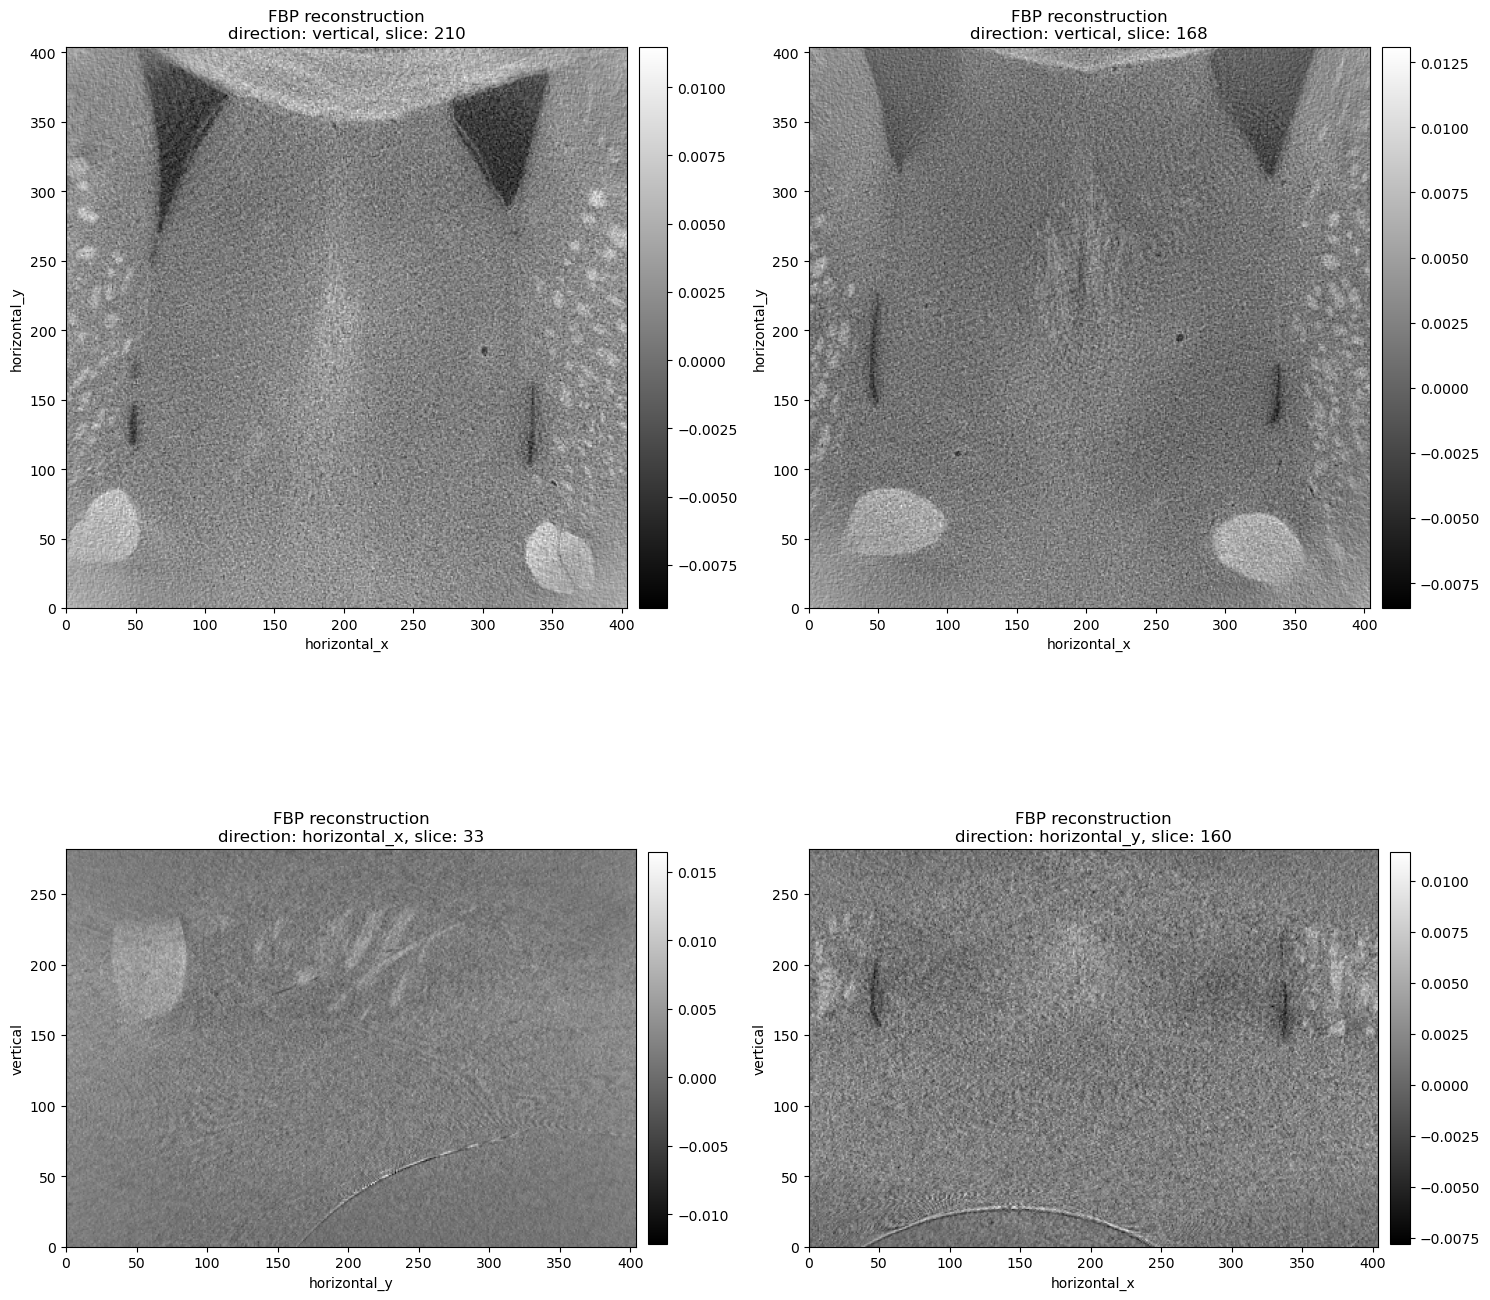

In [9]:
roi = {'horizontal_x':(100,-100,1),'horizontal_y':(100,-100,1)}

processor = Slicer(roi)

processor.set_input(FBP_reco)

FBP_reco_slice= processor.get_output()

slice_list=[('vertical',210),('vertical',168),('horizontal_x',33),('horizontal_y',160)]
_ = show2D(FBP_reco_slice,slice_list=slice_list, title="FBP reconstruction")
